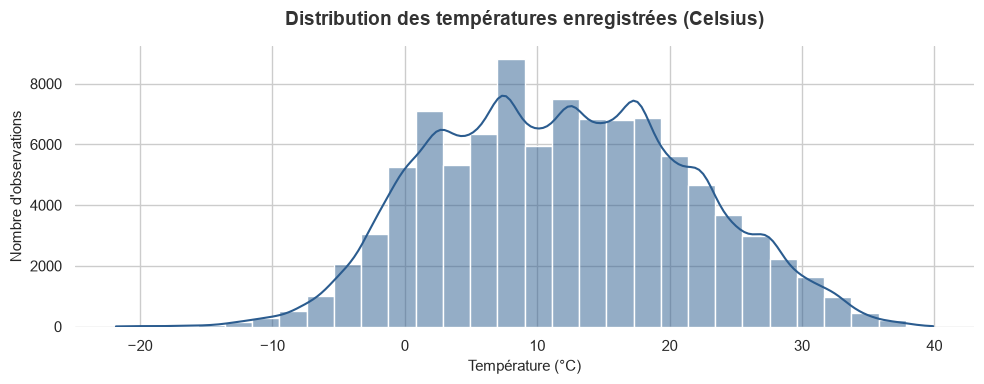

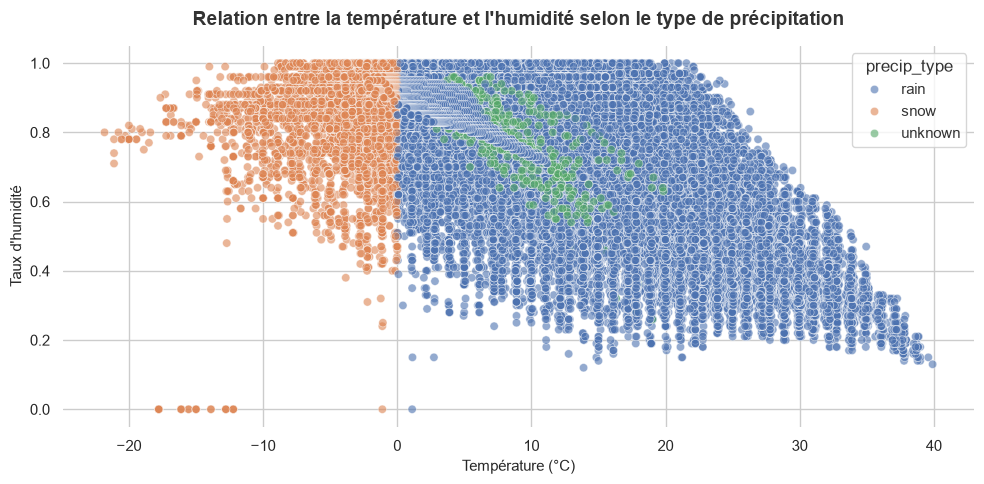

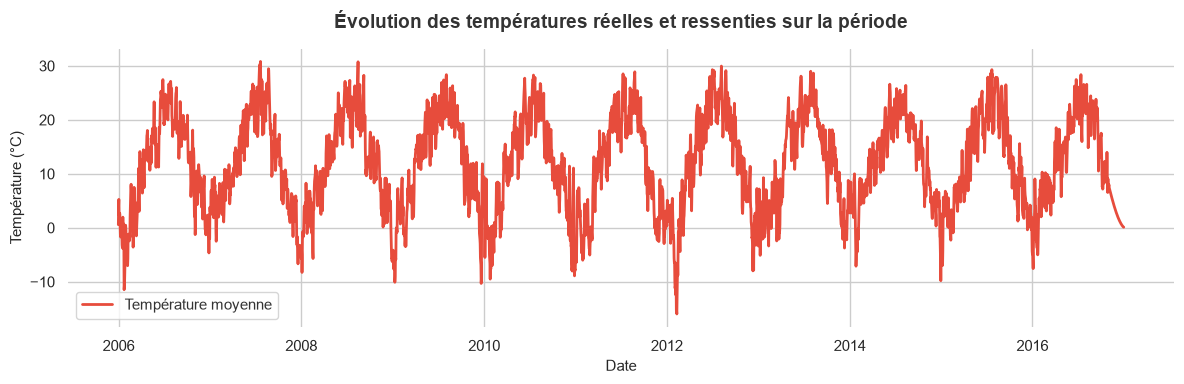

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().resolve().parents[1]))
from analysis.paths import ensure_enriched_csv

df = pd.read_csv(ensure_enriched_csv())
df['date_time'] = pd.to_datetime(df['date_time'])

# --- 1. Histogramme de la température ---
plt.figure(figsize=(10, 5))
sns.histplot(df['temperature_c'], kde=True, color='#3498db', bins=50)
plt.title('Distribution de la température (°C)')
plt.xlabel('Température (°C)')
plt.ylabel('Fréquence')
plt.show()

# --- 2. Nuage de points : Température vs Humidité ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='humidity', y='temperature_c', hue='precip_type', alpha=0.3, s=10)
plt.title('Température vs Humidité (par type de précipitation)')
plt.xlabel('Humidité')
plt.ylabel('Température (°C)')
plt.show()

# --- 3. Évolution temporelle (température moyenne journalière) ---
df_daily = df.resample('D', on='date_time').mean(numeric_only=True).reset_index()

plt.figure(figsize=(12, 5))
plt.plot(df_daily['date_time'], df_daily['temperature_c'], label='Température moyenne', color='#2ecc71', linewidth=1.5)
if 'apparent_temperature_c' in df_daily.columns:
    plt.plot(df_daily['date_time'], df_daily['apparent_temperature_c'], label='Ressenti moyen', color='#f39c12', linewidth=1.5, linestyle='--')
plt.title('Évolution journalière de la température')
plt.xlabel('Date')
plt.ylabel('Température (°C)')
plt.legend()
plt.show()
